# Titanic Dataset Exploratory Data Analysis

This project performs a mini Exploratory Data Analysis (EDA) on the Titanic dataset.

The objective is to clean the data, handle missing values, and explore survival patterns using visualization and statistical analysis.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Titanic-Dataset (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

The following steps were performed:
- Missing values in Age were filled using the mean.
- Missing values in Embarked were filled using the mode.
- The Cabin column was dropped due to excessive missing values.
- New features such as AgeGroup and FamilySize were created.

In [21]:
# Fill missing Age
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Drop Cabin if present
df.drop(columns=["Cabin"], inplace=True, errors="ignore")

# Fill missing Embarked
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [7]:
# Age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Family size
df["FamilySize"] = df["SibSp"] + df["Parch"]

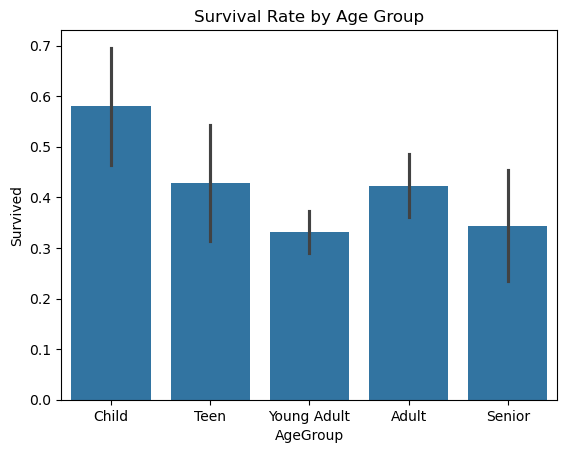

In [8]:
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

### Insight

- Children and young passengers had higher survival rates.
- This suggests priority was given to children during evacuation.

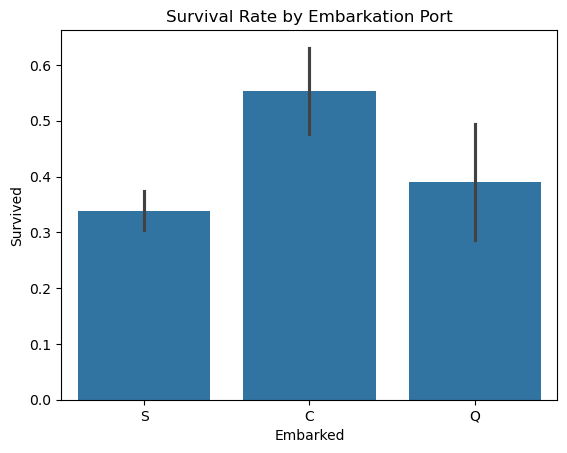

In [10]:
sns.barplot(x="Embarked", y="Survived", data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()

### Insight

- Passengers from Port C had higher survival rates.
- This may be because more first-class passengers boarded from this port.

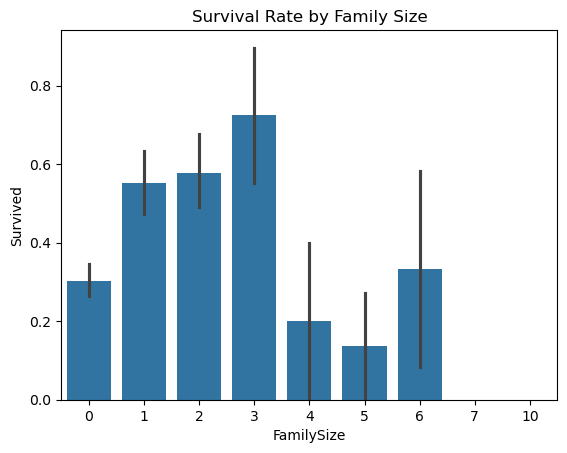

In [11]:
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

### Insight

- Small families had better survival chances.
- Very large families struggled to escape.

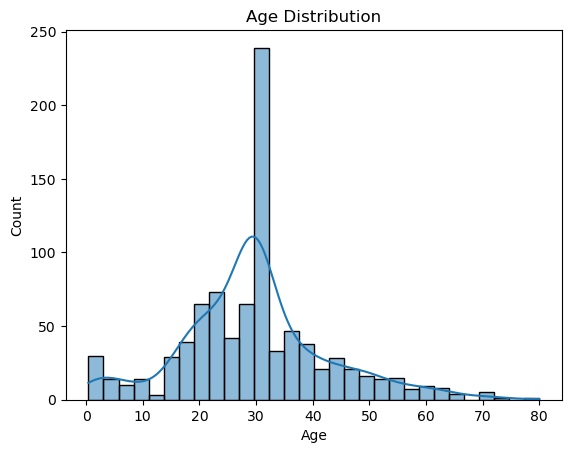

In [12]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

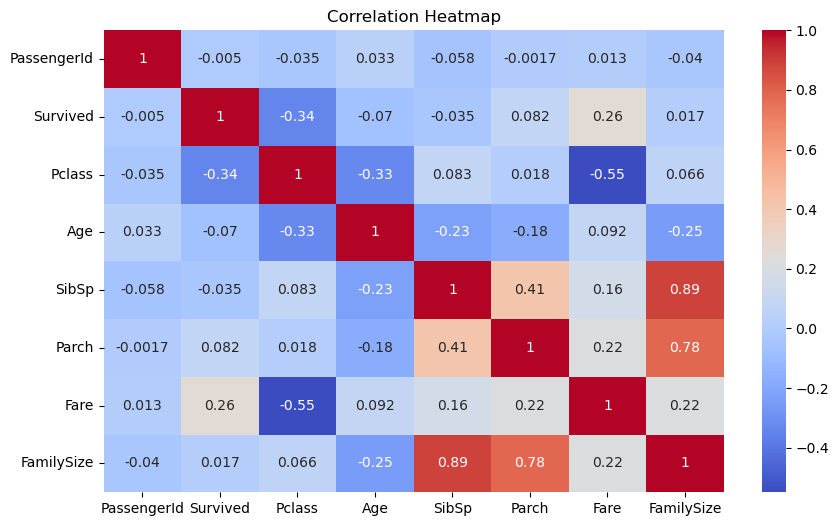

In [15]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

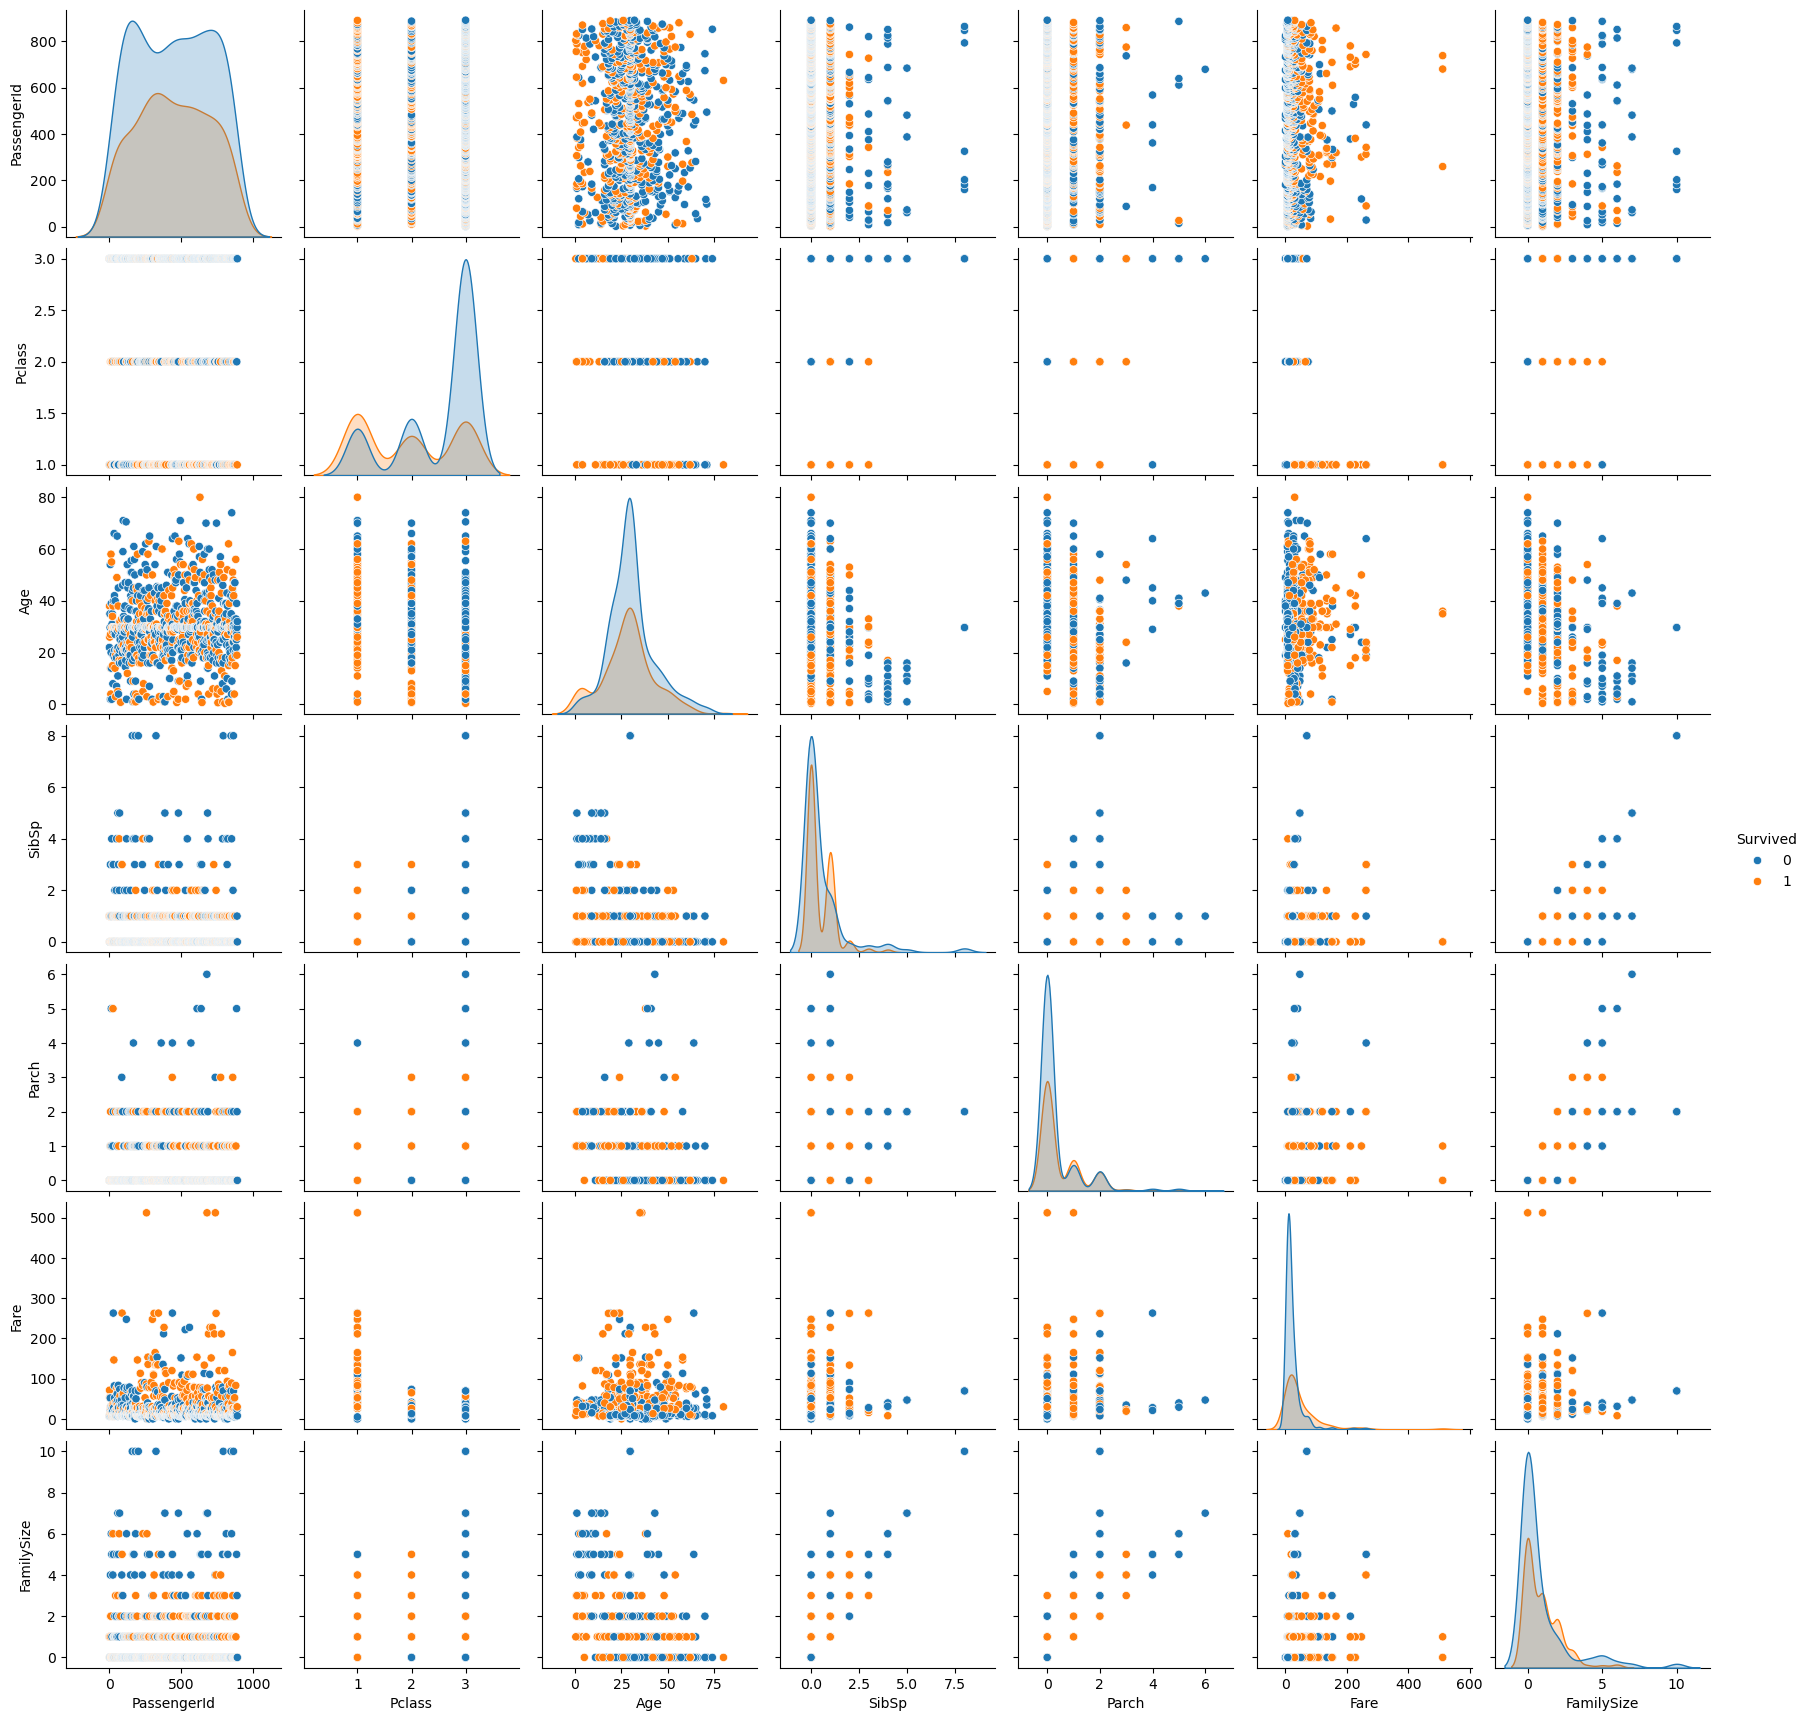

In [22]:
sns.pairplot(df, hue="Survived")
plt.show()

## Conclusion

From this analysis, the following insights were observed:

1. Women and children had the highest survival probability.
2. Higher-class passengers had better chances of survival.
3. Medium-sized families had higher survival.
4. Age and class strongly influenced survival.
5. Data visualization helps in discovering hidden patterns.

This project helped strengthen my skills in:
- Data cleaning
- Feature engineering
- Data visualization
- Exploratory Data Analysis (EDA)

## Future Work

- Apply machine learning models to predict survival.
- Perform advanced feature engineering.
- Use deep learning for classification.